# Thalweg 13 years

In [2]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as NC
import itertools
from matplotlib import pylab
import sys 
from matplotlib.colors import LogNorm

#
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [3]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [4]:
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)

In [5]:
thalweg= np.loadtxt('my_thalweg.txt', delimiter=' ', dtype=int)

In [6]:
def distance(thalweg,dx,dy):
    leng=thalweg.shape
    l =leng[0]
    distance = np.zeros(l)
    d=0
    
    for k in range(1,l):
        i1=thalweg[k-1,1]; i2=thalweg[k,1];
        j1=thalweg[k-1,0]; j2=thalweg[k,0];
        dseg =( (dx*(i2-i1))**2 + (dy*(j2-j1))**2)**(0.5)
        d=d+dseg
        distance[k]=d;

    return distance

In [7]:
dist = distance(thalweg, dx=400, dy=500); dist=dist/1000

In [8]:
bat_mask = []
for i in range(0,len(dist)-1):
    bat_mask.append(bathy['Bathymetry'][thalweg[i][0], thalweg[i][1]].values)

In [9]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [10]:
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)

In [11]:
from scipy.spatial import cKDTree

def get_grid_indices_vectorized(part_lons, part_lats, mask):
    #
    grid_lats = mask.nav_lat.values.flatten()
    grid_lons = mask.nav_lon.values.flatten()
    tree = cKDTree(np.c_[grid_lats, grid_lons])
    
    #
    _, indices = tree.query(np.c_[part_lats, part_lons])
    
    #
    shape_x = mask.nav_lon.shape[1]
    return indices // shape_x, indices % shape_x

In [12]:

from matplotlib.colors import LogNorm

def create_robust_swath(data, thalweg, mask, d_km, dd=17, num_z_bins=40):
    status = data['status'].values.flatten()
    idx_wat = (status > 0) & (status < 4)
    
    p_lons = data['lon'].values.flatten()[idx_wat]
    p_lats = data['lat'].values.flatten()[idx_wat]
    p_depths = data['z'].values.flatten()[idx_wat]

    #
    p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)

    # 3. Create 3D Histogram (Z, Y, X)
    y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)
    x_bins = np.arange(0, mask.nav_lat.shape[1] + 1)
    z_bins = np.linspace(0, 450, num_z_bins + 1) # Adjust max depth to your bathy
    
    grid_3d, _ = np.histogramdd(
        (p_depths, p_y, p_x), 
        bins=(z_bins, y_bins, x_bins)
    )

    # 4. Swath Extraction with tmask
    tmask = mask['tmask'][0, 0].values
    swath_matrix = np.zeros((num_z_bins, len(thalweg)))

    print("Sliding swath box along thalweg...")
    for i, pt in enumerate(thalweg):
        y_c, x_c = int(pt[0]), int(pt[1])
        
        # Define box bounds with grid clipping
        y0, y1 = max(0, y_c - dd), min(grid_3d.shape[1], y_c + dd + 1)
        x0, x1 = max(0, x_c - dd), min(grid_3d.shape[2], x_c + dd + 1)
        
        # Local mask for the box
        local_mask = tmask[y0:y1, x0:x1]
        
        for k in range(num_z_bins):
            # Only sum counts where tmask == 1 (water)
            box_counts = grid_3d[k, y0:y1, x0:x1]
            swath_matrix[k, i] = np.sum(box_counts[local_mask == 1])

    return swath_matrix, z_bins

In [13]:
def smooth_array(data, window_size=5):
    """Smooths array using a moving average while maintaining length."""
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(data, window, 'same')

bat_mask_raw = np.array(bat_mask)
bat_mask_smooth = smooth_array(bat_mask_raw, window_size=7) 

bat_mask_smooth[0] = bat_mask_raw[0]
bat_mask_smooth[-1] = bat_mask_raw[-1]

In [14]:
thalweg_lats = mask.nav_lat.values[thalweg[:,0], thalweg[:,1]]
thalweg_lons = mask.nav_lon.values[thalweg[:,0], thalweg[:,1]]

dist_to_source = np.sqrt((thalweg_lats - source_lat)**2 + (thalweg_lons - source_lon)**2)
source_idx = np.argmin(dist_to_source)

source_dist_km = dist[source_idx]

In [15]:
file_year1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
file_year2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
file_year3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
file_year4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
file_year5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
file_year6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
file_year7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
file_year8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
file_year9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'
file_year10 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc'
file_year11 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc'
file_year12 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc'
file_year13 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_13.nc'

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.patches import Polygon

plt.rcParams.update({'font.size': 28})

# =========================================================
# 1. Configuration & Initialization
# =========================================================
all_files = [
    file_year1, file_year2, file_year3, file_year4, file_year5, 
    file_year6, file_year7, file_year8, file_year9, file_year10, 
    file_year11, file_year12, file_year13
]

num_z_bins = 40
dd = 17 # Thalweg box half-width

# Initialize accumulation arrays
total_swath_matrix = np.zeros((num_z_bins, len(thalweg)))

# Using grid bins (0 to 397/897) for perfect alignment with X, Y meshgrid
y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)
x_bins = np.arange(0, mask.nav_lon.shape[1] + 1)
total_map_hist = np.zeros((mask.nav_lat.shape[0], mask.nav_lon.shape[1]))

# =========================================================
# 2. Iterate Through All 13 Years to Sum the Data
# =========================================================
print("Accumulating data over 13 years. This may take a few minutes...")

for idx, file in enumerate(all_files):
    print(f"Processing Year {idx + 1}...")
    data = xr.open_dataset(file)
    
    # A. Accumulate Thalweg Swath
    swath_matrix, z_bins = create_robust_swath(data, thalweg, mask, d_km=400, dd=dd, num_z_bins=num_z_bins)
    total_swath_matrix += swath_matrix
    
    # B. Accumulate Map Distribution using Grid Indices
    status = data['status'].values.flatten()
    idx_wat = (status > 0) & (status < 4)
    p_lons = data['lon'].values.flatten()[idx_wat]
    p_lats = data['lat'].values.flatten()[idx_wat]
    
    # Convert lat/lon to grid indices using your vectorized function
    p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)
    
    # Histogram over the grid
    hist, _, _ = np.histogram2d(p_y, p_x, bins=[y_bins, x_bins])
    total_map_hist += hist
    
    data.close() # Free up memory

print("Accumulation complete! Plotting...")

# =========================================================
# 3. Format Data for Plotting
# =========================================================
# Replace 0s with NaNs for logarithmic plotting
total_swath = np.where(total_swath_matrix == 0, np.nan, total_swath_matrix)
total_amount = np.where(total_map_hist == 0, np.nan, total_map_hist)

# Extract Z centers for contouring
z_centers = z_bins[:-1] 


x = np.linspace(0, mask.nav_lon.shape[1]-1, mask.nav_lon.shape[1])
y = np.linspace(0, mask.nav_lat.shape[0]-1, mask.nav_lat.shape[0])
X, Y = np.meshgrid(x, y)

Accumulating data over 13 years. This may take a few minutes...
Processing Year 1...
Sliding swath box along thalweg...
Processing Year 2...
Sliding swath box along thalweg...
Processing Year 3...
Sliding swath box along thalweg...
Processing Year 4...
Sliding swath box along thalweg...
Processing Year 5...
Sliding swath box along thalweg...
Processing Year 6...
Sliding swath box along thalweg...
Processing Year 7...
Sliding swath box along thalweg...
Processing Year 8...
Sliding swath box along thalweg...
Processing Year 9...
Sliding swath box along thalweg...
Processing Year 10...
Sliding swath box along thalweg...
Processing Year 11...
Sliding swath box along thalweg...
Processing Year 12...
Sliding swath box along thalweg...
Processing Year 13...
Sliding swath box along thalweg...
Accumulation complete! Plotting...


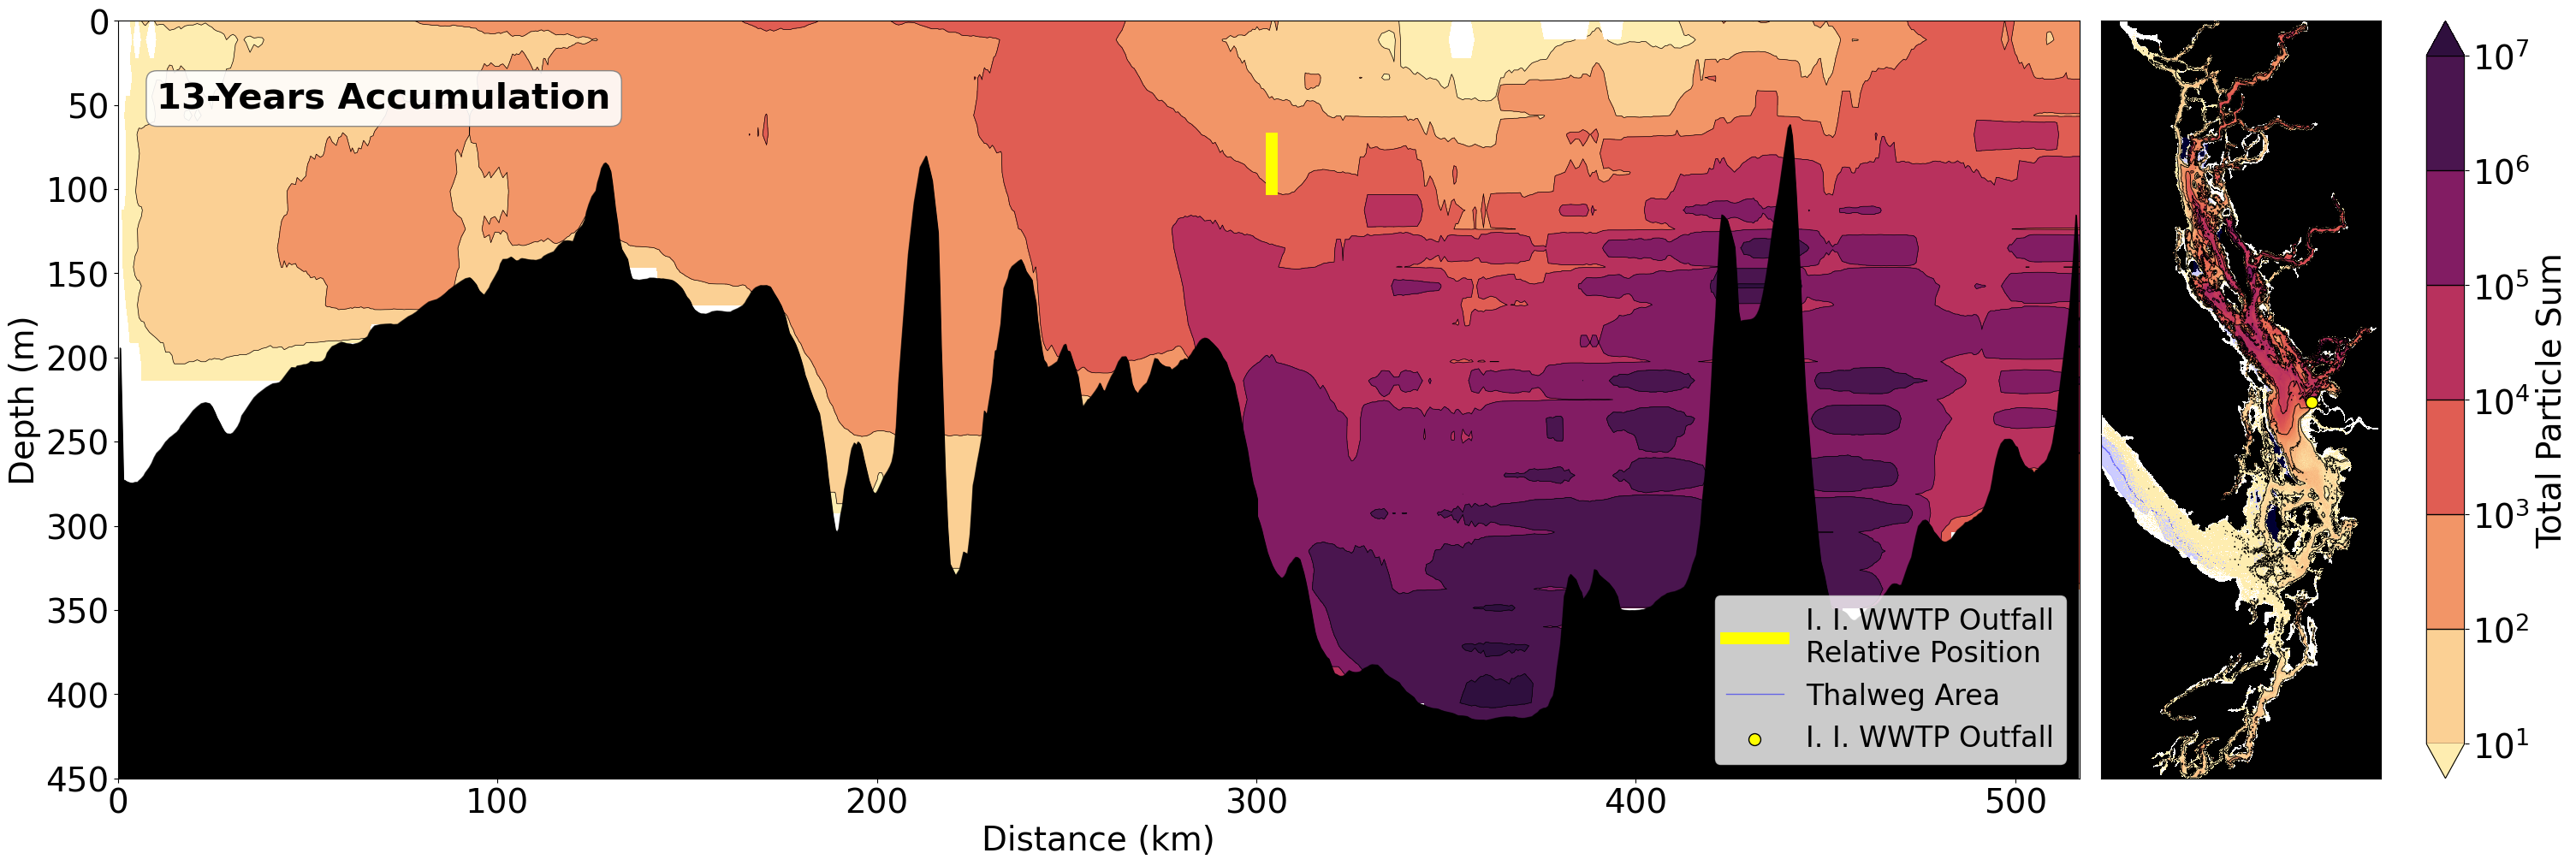

In [ ]:
levels = [10, 100, 1000, 10000, 100000, 1000000, 10000000] # Adjust if maximum accumulation exceeds 10^6
colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]
cmap_mask = ListedColormap(colors_0)

fig, axes = plt.subplots(1, 2, figsize=(30, 10), 
                         layout='constrained',
                         gridspec_kw={'width_ratios': [4, 0.6], 'wspace': 0.0})

bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9)

ax_left = axes[0]
ax_right = axes[1]

# Ensure correct transposition for the swath data
current_swath = total_swath if total_swath.shape[1] == len(dist) else total_swath.T

#
cntr = ax_left.contourf(dist, z_centers, current_swath, 
                        levels=levels, cmap=cm.matter,
                        norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                        extend='both', zorder=1)

ax_left.contour(dist, z_centers, current_swath, 
                levels=levels, colors='black', 
                linewidths=0.5, zorder=2)

# bat_mask_smooth is length len(dist)-1 based on your original loop
ax_left.fill_between(dist[:-1], bat_mask_smooth, 450, color='k', zorder=3)
ax_left.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=4)

ax_left.plot([source_dist_km, source_dist_km], [70,100], 'yellow', linewidth=10, 
             label='I. I. WWTP Outfall\nRelative Position')

ax_left.invert_yaxis()
ax_left.set_ylim(450, 0)
ax_left.set_xlim(dist.min(), dist.max())
ax_left.set_ylabel("Depth (m)")
ax_left.set_xlabel('Distance (km)')

# Top-left label for thalweg plot
ax_left.text(0.02, 0.92, '13-Years Accumulation', transform=ax_left.transAxes, fontsize=30,
             fontweight='bold', verticalalignment='top', bbox=bbox_props, zorder=5)

#
# Plot the land mask
ax_right.pcolormesh(X, Y, mask['tmask'][0][0], cmap=cmap_mask, zorder=0)

# Plot the accumulated particle distribution
ax_right.pcolormesh(X, Y, total_amount, 
                    norm=LogNorm(vmin=levels[0], vmax=levels[-1]), cmap=cm.matter, zorder=3)

ax_right.contour(X, Y, total_amount, 
                 colors='black', levels=levels, linewidths=0.7, linestyles='solid', zorder=4)

# Plot Thalweg Area Polygon
left_side_x = thalweg[:, 1] - dd
left_side_y = thalweg[:, 0]
right_side_x = thalweg[:, 1] + dd
right_side_y = thalweg[:, 0]

verts = [
    *zip(left_side_x, left_side_y),
    *zip(right_side_x[::-1], right_side_y[::-1])
]
poly = Polygon(verts, facecolor='b', alpha=0.2, edgecolor='b', linewidth=0.5, zorder=2)
ax_right.add_patch(poly)

# Plot Thalweg Line and Source
ax_right.plot(thalweg[:, 1], thalweg[:, 0], color='b', alpha=0.5, linewidth=1, label='Thalweg Area', zorder=2)
s_y, s_x = finder2(source_lat, source_lon, mask)
ax_right.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='I. I. WWTP Outfall')

# Map formatting
ax_right.set_xlim(20, 398)
ax_right.set_aspect(1.14)
ax_right.set_anchor('W')    
ax_right.set_xticks([])
ax_right.set_yticks([])

#
# Grab the drawn objects and labels from BOTH subplots
handles_left, labels_left = ax_left.get_legend_handles_labels()
handles_right, labels_right = ax_right.get_legend_handles_labels()

# Combine them and plot the master legend on the left subplot
ax_left.legend(handles_left + handles_right, labels_left + labels_right, 
               loc='lower right', fontsize=24)

# ONE MASTER COLORBAR FOR THE WHOLE FIGURE
cbar = fig.colorbar(cntr, ax=axes, orientation='vertical', fraction=0.03, pad=0.02, ticks=levels)
cbar.set_label('Total Particle Sum')

# Format scientific notation
cbar.ax.set_yticklabels([f'$10^{{{int(np.log10(l))}}}$' for l in levels])

# Add horizontal marker lines across the colorbar
for lev in levels:
    cbar.ax.hlines(lev, *cbar.ax.get_xlim(), colors='black', linewidth=1)

plt.show()

# Instead of accumulation, let's get a mean spatial distribution and std

In [ ]:
import cmocean.cm as cm
import copy
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as NC
import itertools
import sys 

from matplotlib import pyplot as plt, colors, pylab
from matplotlib.colors import LogNorm, ListedColormap, SymLogNorm
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from scipy.spatial import cKDTree
from matplotlib.patches import Polygon

plt.rcParams.update({'font.size': 22})

# Load Grids and Masks
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = mask['volume']

# Meshgrid for plotting
x = np.linspace(0, mask.nav_lon.shape[1]-1, mask.nav_lon.shape[1])
y = np.linspace(0, mask.nav_lat.shape[0]-1, mask.nav_lat.shape[0])
X, Y = np.meshgrid(x, y)

In [ ]:
def finder2(target_lat, target_lon, mask=mask):
    lat = mask.nav_lat
    lon = mask.nav_lon
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

def get_grid_indices_vectorized(part_lons, part_lats, mask):
    grid_lats = mask.nav_lat.values.flatten()
    grid_lons = mask.nav_lon.values.flatten()
    tree = cKDTree(np.c_[grid_lats, grid_lons])
    _, indices = tree.query(np.c_[part_lats, part_lons])
    shape_x = mask.nav_lon.shape[1]
    return indices // shape_x, indices % shape_x

# Iona Island WWTP Outfall Coordinates
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)

# Thalweg Setup
thalweg = np.loadtxt('my_thalweg.txt', delimiter=' ', dtype=int)
dd = 17 # Thalweg box half-width

In [ ]:
# File definitions
all_files = [
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_13.nc'
]

# Grid Bins
y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)
x_bins = np.arange(0, mask.nav_lon.shape[1] + 1)

# INITIALIZE 3D ARRAY (13 Years, Y, X)
num_years = len(all_files)
all_maps_hist = np.zeros((num_years, mask.nav_lat.shape[0], mask.nav_lon.shape[1]))

print("Processing 13 years into a 3D array...")

for idx, file in enumerate(all_files):
    print(f"Extracting Map Data for Year {idx + 1}...")
    data = xr.open_dataset(file)
    
    status = data['status'].values.flatten()
    idx_wat = (status > 0) & (status < 4)
    p_lons = data['lon'].values.flatten()[idx_wat]
    p_lats = data['lat'].values.flatten()[idx_wat]
    
    p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)
    
    # Store each year in its specific index along the first dimension
    hist, _, _ = np.histogram2d(p_y, p_x, bins=[y_bins, x_bins])
    all_maps_hist[idx] = hist
    
    data.close()

print("Data processing complete.")

Processing 13 years into a 3D array...
Extracting Map Data for Year 1...


Extracting Map Data for Year 2...
Extracting Map Data for Year 3...
Extracting Map Data for Year 4...
Extracting Map Data for Year 5...
Extracting Map Data for Year 6...
Extracting Map Data for Year 7...
Extracting Map Data for Year 8...
Extracting Map Data for Year 9...
Extracting Map Data for Year 10...
Extracting Map Data for Year 11...
Extracting Map Data for Year 12...
Extracting Map Data for Year 13...
Data processing complete.


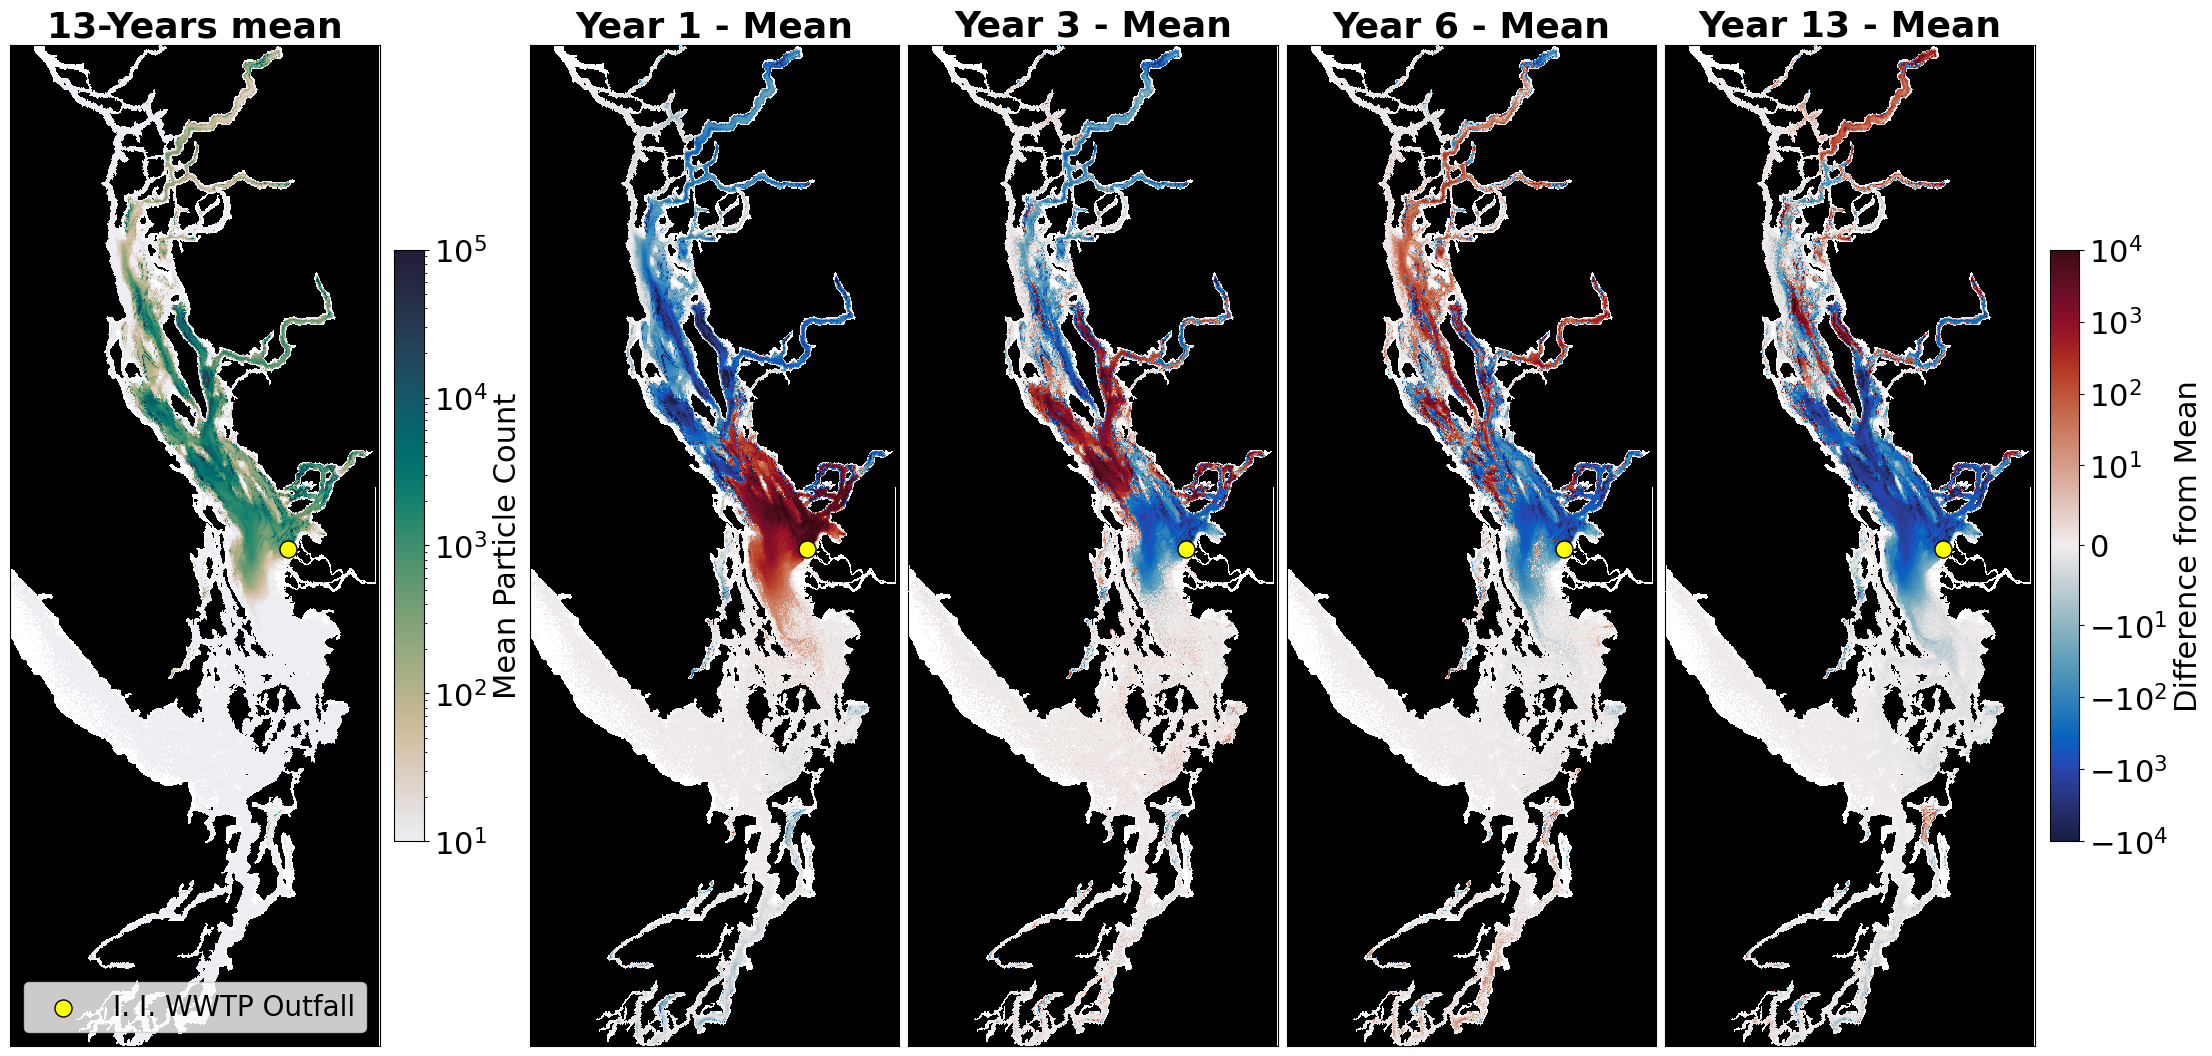

In [ ]:
# 1. Calculate the Spatial Mean Map across all 13 years
mean_map_hist = np.mean(all_maps_hist, axis=0)
mean_amount = np.where(mean_map_hist == 0, np.nan, mean_map_hist)

# 2. Extract specific years (0-indexed: Year 1=0, Year 6=5, Year 13=12)
data_y1 = all_maps_hist[0]
data_y3 = all_maps_hist[2]
data_y6 = all_maps_hist[5]
data_y13 = all_maps_hist[12]

# 3. Calculate Differences (Data - Mean)
anomaly_y1 = data_y1 - mean_map_hist
anomaly_y3 = data_y3 - mean_map_hist
anomaly_y6 = data_y6 - mean_map_hist
anomaly_y13 = data_y13 - mean_map_hist

# Format arrays for plotting (handling zeros)
anomaly_plot_y1 = np.where(anomaly_y1 == 0, np.nan, anomaly_y1)
anomaly_plot_y3 = np.where(anomaly_y3 == 0, np.nan, anomaly_y3)
anomaly_plot_y6 = np.where(anomaly_y6 == 0, np.nan, anomaly_y6)
anomaly_plot_y13 = np.where(anomaly_y13 == 0, np.nan, anomaly_y13)

# Determine the absolute max anomaly across ALL selected years for a consistent colorbar
max_diff = np.nanmax([np.abs(anomaly_y1), np.abs(anomaly_y3), np.abs(anomaly_y6), np.abs(anomaly_y13)])

# Colormaps and Levels
levels_mean = [10, 100, 1000, 10000, 100000] 
colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]
cmap_mask = ListedColormap(colors_0)

# 4. Set up the 4-panel figure
fig, axes = plt.subplots(1, 5, figsize=(22, 15), layout='constrained')
ax_mean, ax_y1, ax_y3, ax_y6, ax_y13 = axes
#bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.6) # Lowered to 0.6
# ==========================================
# PANEL 1: 13-Year Mean Map
# ==========================================
ax_mean.pcolormesh(X, Y, mask['tmask'][0][0], cmap=cmap_mask, zorder=0)

mean_plot = ax_mean.pcolormesh(X, Y, mean_amount, 
                               norm=LogNorm(vmin=levels_mean[0], vmax=levels_mean[-1]), 
                               cmap=cm.rain, zorder=3)

ax_mean.scatter(s_x, s_y, color='yellow', edgecolor='black', s=150, zorder=5, label='I. I. WWTP Outfall')
#ax_mean.text(0.04, 0.985, '13-Year Mean', transform=ax_mean.transAxes, fontsize=24,
#             fontweight='bold', verticalalignment='top', horizontalalignment='left', 
#             bbox=bbox_props, zorder=6)
ax_mean.set_title('13-Years mean', fontsize = 26, fontweight = 'bold')
ax_mean.set_xlim(20, 398)
ax_mean.set_aspect(1.14)
ax_mean.set_xticks([])
ax_mean.set_yticks([])
ax_mean.legend(loc='lower center', fontsize=20)

cbar_mean = fig.colorbar(mean_plot, ax=ax_mean, orientation='vertical', fraction=0.08, pad=0.04)
cbar_mean.set_label('Mean Particle Count')

# ==========================================
# HELPER FOR ANOMALY PANELS
# ==========================================
def plot_anomaly_panel(ax, anomaly_data, title_text):
    ax.pcolormesh(X, Y, mask['tmask'][0][0], cmap=cmap_mask, zorder=0)
    
    mesh = ax.pcolormesh(X, Y, anomaly_data, 
                         norm=SymLogNorm(linthresh=10, vmin=-1e4, vmax=1e4, base=10), 
                         cmap=cm.balance, zorder=3)
    
    ax.scatter(s_x, s_y, color='yellow', edgecolor='black', s=150, zorder=5)
    #ax.text(0.04, 0.985, title_text, transform=ax.transAxes, fontsize=24,
    #            fontweight='bold', verticalalignment='top', horizontalalignment='left', 
    #            bbox=bbox_props, zorder=6)
    ax.set_title(title_text, fontsize = 26, fontweight = 'bold')
    ax.set_xlim(20, 398)
    ax.set_aspect(1.14)
    ax.set_xticks([])
    ax.set_yticks([])
    return mesh

# ==========================================
# PANELS 2-4: Anomaly Maps
# ==========================================
mesh_y1 = plot_anomaly_panel(ax_y1, anomaly_plot_y1, 'Year 1 - Mean')
mesh_y3 = plot_anomaly_panel(ax_y3, anomaly_plot_y3, 'Year 3 - Mean')
mesh_y6 = plot_anomaly_panel(ax_y6, anomaly_plot_y6, 'Year 6 - Mean')
mesh_y13 = plot_anomaly_panel(ax_y13, anomaly_plot_y13, 'Year 13 - Mean')

# Colorbar for Anomalies (Attached only to the final panel to serve all three)
cbar_anom = fig.colorbar(mesh_y13, ax=ax_y13, orientation='vertical', fraction=0.08, pad=0.04)
cbar_anom.set_label('Difference from Mean')

plt.show()

# Proportions after all

In [16]:
def proportions(data):
    # 1. Extract underlying NumPy arrays
    status = data.status.values
    lat = data.lat.values
    lon = data.lon.values

    # 2. Create valid mask and totals
    valid_mask = np.isfinite(status) & np.isfinite(lat) & np.isfinite(lon)
    total_len = np.sum(valid_mask, axis=0).astype(float)

    # 3. Use lambda functions to evaluate conditions LAZILY.
    # This prevents creating 9 huge arrays in memory at the same time.
    categories = {
        'initial': lambda s: s < 0,
        'sewage_water': lambda s: s == 1,
        'colloidal_water': lambda s: s == 2,
        'marine_water': lambda s: s == 3,
        'out_jdf': lambda s: s == 7,
        'out_js': lambda s: s == 8,
        'sewage_sediment': lambda s: s == 11,
        'colloidal_sediment': lambda s: s == 12,
        'marine_sediment': lambda s: s == 13
    }

    results = {}
    
    # 4. Process one category at a time
    with np.errstate(invalid='ignore', divide='ignore'):
        for name, func in categories.items():
            # Evaluate the condition on the fly
            condition = func(status)
            counts = np.sum(condition & valid_mask, axis=0).astype(float)
            
            counts = np.where(total_len == 0, np.nan, counts)
            pcts = (counts / total_len) * 100
            
            results[f'{name}_count'] = counts
            results[f'{name}_pct'] = pcts

    results['total_len'] = total_len
    data_proportions = pd.DataFrame(results)

    # 5. Extract time index safely
    if hasattr(data, 'time'):
        # Checks if time is 1D (typical) or 2D (like time[particles, obs])
        time_vals = data.time.values if data.time.ndim == 1 else data.time[0, :].values
        data_proportions.index = pd.to_datetime(time_vals)

    return data_proportions

# --- Optimized File Processing Loop ---

all_files = [
    file_year1, file_year2, file_year3, file_year4, file_year5, 
    file_year6, file_year7, file_year8, file_year9, file_year10, 
    file_year11, file_year12, file_year13
]

all_dfs = [] # Store the small resulting DataFrames, not the massive raw Datasets

for idx, file in enumerate(all_files):
    print(f"Processing Year {idx + 1}...")
    # Using 'with' ensures the netCDF file is cleanly closed from memory after reading
    with xr.open_dataset(file) as data:
        df = proportions(data)
        all_dfs.append(df)

# Concatenate the lightweight DataFrames into one continuous timeline
data_total_proportions = pd.concat(all_dfs)

Processing Year 1...
Processing Year 2...
Processing Year 3...
Processing Year 4...
Processing Year 5...
Processing Year 6...
Processing Year 7...
Processing Year 8...
Processing Year 9...
Processing Year 10...
Processing Year 11...
Processing Year 12...
Processing Year 13...


In [25]:
water_proportion = data_total_proportions['colloidal_water_pct'] + data_total_proportions['marine_water_pct']
sediment_proportion = data_total_proportions['colloidal_sediment_pct'] + data_total_proportions['marine_sediment_pct']
out_system_proportion = data_total_proportions['out_jdf_pct'] + data_total_proportions['out_js_pct']

In [34]:
water_proportion.iloc[2920]

87.0291095890411

In [35]:
sediment_proportion.iloc[2920]

12.93664383561644

In [28]:
out_system_proportion.iloc[-1]

0.4909236214179701

# Proportions per depth layer

In [29]:
import xarray as xr
import numpy as np
import pandas as pd

def depth_proportions(data):
    # 1. Extract the underlying NumPy array for depth
    # Change 'z' to 'depth' if that is what your dataset uses
    z = data.z.values

    # 2. Create a valid mask (ignoring NaNs)
    # If you also need to ensure lat/lon are valid, you can include them here 
    # like in the previous script: np.isfinite(z) & np.isfinite(lat) & np.isfinite(lon)
    valid_mask = np.isfinite(z)
    
    # Calculate total valid particles per time step
    total_len = np.sum(valid_mask, axis=0).astype(float)

    # 3. Define depth ranges using lambda functions for lazy evaluation
    depth_bins = {
        'depth_0_50m': lambda d: (d >= 0) & (d < 50),
        'depth_50_200m': lambda d: (d >= 50) & (d < 200),
        'depth_200_450m': lambda d: (d >= 200) & (d <= 450)
    }

    results = {}
    
    # 4. Calculate counts and percentages
    with np.errstate(invalid='ignore', divide='ignore'):
        for name, func in depth_bins.items():
            # Evaluate the depth condition on the fly
            condition = func(z)
            
            # Count occurrences where condition is met AND the particle is valid
            counts = np.sum(condition & valid_mask, axis=0).astype(float)
            
            # Handle empty time steps
            counts = np.where(total_len == 0, np.nan, counts)
            
            # Calculate percentages
            pcts = (counts / total_len) * 100
            
            results[f'{name}_count'] = counts
            results[f'{name}_pct'] = pcts

    results['total_len'] = total_len
    
    # 5. Construct DataFrame
    df_depths = pd.DataFrame(results)

    # Extract time index safely
    if hasattr(data, 'time'):
        time_vals = data.time.values if data.time.ndim == 1 else data.time[0, :].values
        df_depths.index = pd.to_datetime(time_vals)

    return df_depths

# --- File Processing Loop ---

all_files = [
    file_year1, file_year2, file_year3, file_year4, file_year5, 
    file_year6, file_year7, file_year8, file_year9, file_year10, 
    file_year11, file_year12, file_year13
]

all_depth_dfs = [] 

for idx, file in enumerate(all_files):
    print(f"Processing Year {idx + 1} for depths...")
    with xr.open_dataset(file) as data:
        df = depth_proportions(data)
        all_depth_dfs.append(df)

# Concatenate the final results
depth_proportions_total = pd.concat(all_depth_dfs)

Processing Year 1 for depths...
Processing Year 2 for depths...
Processing Year 3 for depths...
Processing Year 4 for depths...
Processing Year 5 for depths...
Processing Year 6 for depths...
Processing Year 7 for depths...
Processing Year 8 for depths...
Processing Year 9 for depths...
Processing Year 10 for depths...
Processing Year 11 for depths...
Processing Year 12 for depths...
Processing Year 13 for depths...


In [31]:
depth_proportions_total['depth_0_50m_pct'].iloc[-1]

0.9618677931270694

In [32]:
depth_proportions_total['depth_50_200m_pct'].iloc[-1]

34.01073181870076

In [33]:
depth_proportions_total['depth_200_450m_pct'].iloc[-1]

65.02740038817217